# 02 - Fusion: how lexical and dense results are merged, and whether one deserves less weight

**The mechanism in one paragraph.** For each message the KB runs two searches: a *lexical* one (Postgres full-text,
ranked by `ts_rank_cd`) and a *dense* one (bge embeddings, ranked by cosine similarity). Each returns its top 20.
They are merged with **reciprocal-rank fusion (RRF)**: a passage at rank *r* in a list earns `weight / (60 + r)`,
and its fused score is the sum over the two lists (weights are 1 and 1 in production). Only *ranks* matter, the two
raw scores (which are on incomparable scales) are thrown away. The top 20 fused passages go to the **cross-encoder
reranker**, whose logit *replaces* the fused score: after that step the RRF score only breaks ties.

**Questions answered here**
1. Does the pool the reranker sees (fused top 20) contain a passage that answers the question? (*candidate recall@20*)
2. Does giving the lexical list a lower or higher weight change hit@1 / hit@5 / MRR / nDCG@5, with and without rerank?
3. Is any difference larger than noise, given only 89 queries? (bootstrap 95% confidence intervals)
4. How often do the two searches even agree?

| | |
|---|---|
| **Required caches** | `cache/runs/R0_lex.json, R1_dense.json, R2_rrf.json, R3_current.json, FUS_rrf_wl{0.25,0.5,1,2,4}[+rerank].json, FUS_lin_wl{0,0.25,0.5,0.75,1}[+rerank].json` - produced by `uv run python -m experiments.run_variants` (no LLM). |
| **Needed for sections 4-6** | `cache/judgments.json` (and `pools.json`): `uv run python -m experiments.build_pools` then `uv run --env-file .env python -m experiments.llm.judge`. Sections 1-3 need only the runs. |

Variant names: `FUS_rrf_wl<w>` = weighted RRF with lexical weight *w* and dense weight 1 (w = 1 is production);
`FUS_lin_wl<w>` = min-max-normalise each list's scores, then `w*lexical + (1-w)*dense` (w = 0 dense only, w = 1 lexical only);
`+rerank` = cross-encoder rerank of that fused top 20.

In [1]:
import sys, pathlib, math, warnings
warnings.filterwarnings("ignore")
_here = pathlib.Path.cwd().resolve()
REPO = next(p for p in [_here, *_here.parents] if (p / "experiments" / "lab").is_dir())
sys.path[:0] = [str(REPO), str(REPO / "experiments")]

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from lab import notebook_utils as nu

pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 40)
pd.set_option("display.max_colwidth", 80)
pd.set_option("display.float_format", lambda x: f"{x:.3f}")
plt.rcParams.update({"figure.dpi": 100, "axes.spines.top": False, "axes.spines.right": False, "axes.grid": False})
print("cache directory:", nu.cache_dir())

cache directory: /home/user/cato-networks/experiments/cache


In [2]:
FAMS = {"rrf": [0.25, 0.5, 1, 2, 4], "lin": [0, 0.25, 0.5, 0.75, 1]}
def vname(fam, w, rerank): return f"FUS_{fam}_wl{w:g}" + ("+rerank" if rerank else "")
ALL = ["R0_lex", "R1_dense", "R2_rrf", "R3_current"] + [vname(f, w, r) for f in FAMS for w in FAMS[f] for r in (False, True)]
RUNS = nu.load_runs(ALL)
missing = [n for n in ALL if n not in RUNS]
HAVE_RUNS = not missing
if not nu.need(HAVE_RUNS, f"{len(missing)} run files, e.g. {missing[:3]}", nu.CMD_RUN_VARIANTS):
    print("Partial data: sections that need the missing runs will be skipped or show fewer rows.")
Q = nu.load_queries()
J = nu.load_judgments()
HAVE_J = J is not None
QR = nu.qrels_from(J)
labels = nu.gold_labels(Q, J)
print(f"runs loaded: {len(RUNS)}/{len(ALL)}; judgments: {'yes' if HAVE_J else 'NO -> metric sections will be skipped'}")
if not HAVE_J:
    print("To get judgments run first:", nu.CMD_POOLS, "; then", nu.CMD_JUDGE)

runs loaded: 24/24; judgments: NO -> metric sections will be skipped
To get judgments run first: uv run python -m experiments.build_pools ; then uv run --env-file .env python -m experiments.llm.judge


## 1. The mechanism on one real query

We take one query, read its lexical and dense lists from the cache, and redo the fusion by hand with
`1/(60+rank)`. Then we show what the reranker does to the order.

In [3]:
have = all(n in RUNS for n in ("R0_lex", "R1_dense", "R2_rrf", "R3_current"))
if nu.need(have, "runs R0_lex, R1_dense, R2_rrf, R3_current", nu.CMD_RUN_VARIANTS):
    qid = "Q01"
    lex = {r["passage_id"]: r for r in nu.ranked(RUNS["R0_lex"], qid)}
    den = {r["passage_id"]: r for r in nu.ranked(RUNS["R1_dense"], qid)}
    K = 60
    rows = []
    for pid in set(lex) | set(den):
        lr, dr = lex.get(pid, {}).get("rank"), den.get(pid, {}).get("rank")
        rows.append({"slug": (lex.get(pid) or den.get(pid))["slug"][:48], "lex_rank": lr, "dense_rank": dr,
                     "rrf = 1/(60+lex) + 1/(60+dense)": (1 / (K + lr) if lr else 0) + (1 / (K + dr) if dr else 0), "pid": pid})
    by_hand = pd.DataFrame(rows).sort_values(["rrf = 1/(60+lex) + 1/(60+dense)", "pid"], ascending=[False, True]).reset_index(drop=True)
    rrf_order = [r["passage_id"] for r in nu.ranked(RUNS["R2_rrf"], qid)]
    cur_rows = {r["passage_id"]: r for r in nu.ranked(RUNS["R3_current"], qid)}
    by_hand["rank after RRF (by hand)"] = by_hand.index + 1
    by_hand["rank in cached R2_rrf"] = [rrf_order.index(p) + 1 if p in rrf_order else None for p in by_hand["pid"]]
    by_hand["rerank logit"] = [cur_rows.get(p, {}).get("score") for p in by_hand["pid"]]
    by_hand["rank after rerank"] = [cur_rows.get(p, {}).get("rank") for p in by_hand["pid"]]
    for c in ("lex_rank", "dense_rank", "rank in cached R2_rrf", "rank after rerank"):
        by_hand[c] = by_hand[c].astype("Int64")
    print(f"Query {qid}: {Q.loc[qid, 'text'][:110]}...")
    display(by_hand.drop(columns="pid").head(10))

Query Q01: What is the effective MTU over the Socket-to-PoP DTLS tunnel, and what does the Socket do with an oversized WA...


,slug,lex_rank,dense_rank,rrf = 1/(60+lex) + 1/(60+dense),rank after RRF (by hand),rank in cached R2_rrf,rerank logit,rank after rerank
0,socket-mtu-and-dtls-tunnels,7,11,0.029,1,1,0.419,10
1,what-is-socket-ha,10,8,0.029,2,2,2.918,6
2,the-site-experience-monitoring-drill-down-page,4,15,0.029,3,3,-0.953,12
3,cato-cloud-to-fortigate-via-ha-ipsec-tunnels,1,<NA>,0.016,4,4,-11.077,20
4,socket-mtu-and-dtls-tunnels,<NA>,1,0.016,5,5,5.566,1
5,cato-cloud-to-fortigate-via-ha-ipsec-tunnels,2,<NA>,0.016,6,6,-10.143,18
6,socket-mtu-and-dtls-tunnels,<NA>,2,0.016,7,7,4.008,5
7,advanced-configurations-for-a-site,<NA>,3,0.016,8,8,4.074,4
8,cato-cloud-to-fortigate-via-ha-ipsec-tunnels,3,<NA>,0.016,9,9,-10.368,19
9,socket-mtu-and-dtls-tunnels,<NA>,4,0.016,10,10,4.692,2


Read the table from left to right: a passage found by **both** searches near the top (e.g. rank 1 and rank 2) gets a large
fused score; one found by a single search gets about half. `rank after RRF (by hand)` should equal `rank in cached R2_rrf`
(a check that the notebook understands the mechanism; exact ties are broken by passage id, as in production). The last two columns show that the **rerank logit then
re-orders everything**: the fused score no longer decides the top-1 (passages outside the fused top 10 can jump to rank 1,
and they are the reason candidate recall@20 matters: the reranker can only promote what is in the pool).

## 2. Mini-study: how often do the lexical and dense top-10 agree?

If the two searches mostly return the same passages, weights hardly matter. If they disagree, the fusion weight decides
which side wins. This section needs no judgments.

All 89 queries: mean overlap of the two top-10 lists = 1.06 passages; identical top-1 passage in 8%; same top-1 article in 10%; lexical search returned nothing for 0 queries


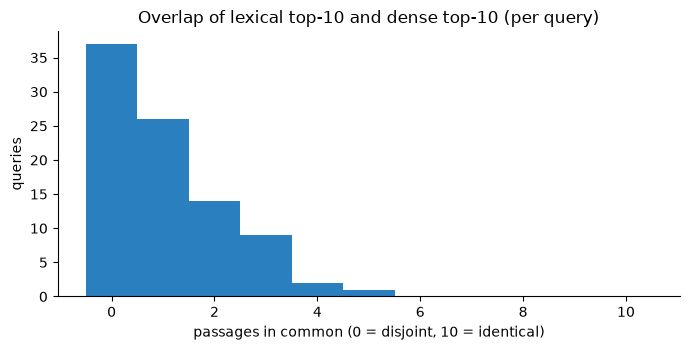

,queries,mean_overlap_of_10,top1_same,same_article_top1,lex_empty
set,,,,,
ANS,35,1.486,0.143,0.200,0
SCN,12,0.583,0.000,0.000,0
TKT,20,0.650,0.050,0.050,0
OOD,10,0.900,0.100,0.100,0
ADJ,12,1.083,0.000,0.000,0


In [4]:
if nu.need("R0_lex" in RUNS and "R1_dense" in RUNS, "runs R0_lex and R1_dense", nu.CMD_RUN_VARIANTS):
    rows = []
    for qid in Q.index:
        L, D = nu.ranked(RUNS["R0_lex"], qid), nu.ranked(RUNS["R1_dense"], qid)
        l10, d10 = [r["passage_id"] for r in L[:10]], [r["passage_id"] for r in D[:10]]
        rows.append({"id": qid, "set": Q.loc[qid, "set"], "lex_n": len(L), "overlap10": len(set(l10) & set(d10)),
                     "top1_same": bool(l10 and d10 and l10[0] == d10[0]),
                     "lex_top1_in_dense10": bool(l10 and l10[0] in d10), "dense_top1_in_lex10": bool(d10 and d10[0] in l10),
                     "same_article_top1": bool(L and D and L[0]["slug"] == D[0]["slug"])})
    ov = pd.DataFrame(rows).set_index("id")
    summary = ov.groupby("set").agg(queries=("overlap10", "size"), mean_overlap_of_10=("overlap10", "mean"),
                                   top1_same=("top1_same", "mean"), same_article_top1=("same_article_top1", "mean"),
                                   lex_empty=("lex_n", lambda s: int((s == 0).sum()))).reindex(nu.SETS)
    print(f"All 89 queries: mean overlap of the two top-10 lists = {ov['overlap10'].mean():.2f} passages; "
          f"identical top-1 passage in {ov['top1_same'].mean():.0%}; same top-1 article in {ov['same_article_top1'].mean():.0%}; "
          f"lexical search returned nothing for {int((ov['lex_n'] == 0).sum())} queries")
    fig, ax = plt.subplots(figsize=(7, 3.6))
    ax.hist(ov["overlap10"], bins=np.arange(-0.5, 11.5, 1), color="#2a7fbf")
    ax.set_title("Overlap of lexical top-10 and dense top-10 (per query)"); ax.set_xlabel("passages in common (0 = disjoint, 10 = identical)"); ax.set_ylabel("queries")
    plt.tight_layout(); plt.show()
    display(summary)

In [5]:
if nu.need(HAVE_J and "overlap10" in globals().get("ov", pd.DataFrame()) , "judgments.json (who found the answer?)", nu.CMD_JUDGE):
    rows = []
    for qid in Q.index:
        g2 = {p for p, g in QR.get(qid, {}).items() if g >= 2}
        if not g2:
            continue
        l10 = {r["passage_id"] for r in nu.ranked(RUNS["R0_lex"], qid)[:10]}
        d10 = {r["passage_id"] for r in nu.ranked(RUNS["R1_dense"], qid)[:10]}
        inl, ind = bool(g2 & l10), bool(g2 & d10)
        rows.append({"id": qid, "found_by": "both" if inl and ind else "lexical only" if inl else "dense only" if ind else "neither (top 10)"})
    fb = pd.DataFrame(rows)
    print("Answerable queries (a grade-2 passage exists): which search has a grade-2 passage in its own top 10?")
    display(fb["found_by"].value_counts().to_frame("queries").assign(share=lambda d: d["queries"] / d["queries"].sum()))

SKIPPED - missing cache: judgments.json (who found the answer?)
  Run step first: uv run --env-file .env python -m experiments.llm.judge


## 3a. What the weight really does: it decides the *pool*, not the fine order

Each search contributes its top 20, and only the fused top 20 go to the reranker. With RRF a passage at lexical rank 20 and weight 2 scores
`2/80 = 0.025`, more than a passage at dense rank 1 (`1/61 = 0.016`). So once the weight of one side is 2 or more (or 0.5 or less), *that side's
20 results fill the whole pool* and the other search only matters where the two lists overlap. The table shows, per weight, where the 20 pool
passages come from (average share over the 89 queries). This needs no judgments.

In [6]:
if nu.need(all(n in RUNS for n in ("R0_lex", "R1_dense", "FUS_rrf_wl1")), "runs R0_lex, R1_dense, FUS_*", nu.CMD_RUN_VARIANTS):
    rows = []
    for fam in FAMS:
        for w in FAMS[fam]:
            n = vname(fam, w, False)
            if n not in RUNS: continue
            shares = []
            for qid in Q.index:
                lex = {r["passage_id"] for r in nu.ranked(RUNS["R0_lex"], qid)[:20]}
                den = {r["passage_id"] for r in nu.ranked(RUNS["R1_dense"], qid)[:20]}
                pool = [r["passage_id"] for r in nu.ranked(RUNS[n], qid)[:20]]
                if pool:
                    shares.append([sum(p in lex and p not in den for p in pool), sum(p in den and p not in lex for p in pool), sum(p in lex and p in den for p in pool), len(pool)])
            a = np.array(shares, dtype=float)
            rows.append({"fusion": f"{fam} w_lex={w:g}", "pool from lexical only": a[:, 0].sum() / a[:, 3].sum(), "pool from dense only": a[:, 1].sum() / a[:, 3].sum(),
                         "pool from both": a[:, 2].sum() / a[:, 3].sum()})
    pool_mix = pd.DataFrame(rows).set_index("fusion")
    display(pool_mix)

,pool from lexical only,pool from dense only,pool from both
fusion,,,
rrf w_lex=0.25,0.000,0.866,0.134
rrf w_lex=0.5,0.000,0.866,0.134
rrf w_lex=1,0.433,0.434,0.134
rrf w_lex=2,0.866,0.000,0.134
rrf w_lex=4,0.866,0.000,0.134
lin w_lex=0,0.053,0.819,0.128
lin w_lex=0.25,0.294,0.582,0.124
lin w_lex=0.5,0.426,0.449,0.125
lin w_lex=0.75,0.564,0.310,0.126


## 3. How much does the weight change what the user sees? (no judgments needed)

For every weight we compare the **final** top-1 (after rerank) and top-5 set with production (RRF weight 1).
If these rarely change, the weights are not where quality is decided.

In [7]:
if nu.need("FUS_rrf_wl1+rerank" in RUNS, "FUS_* runs", nu.CMD_RUN_VARIANTS):
    base = RUNS["FUS_rrf_wl1+rerank"]
    rows = []
    for fam in FAMS:
        for w in FAMS[fam]:
            for rr in (False, True):
                n = vname(fam, w, rr)
                if n not in RUNS: continue
                same1, ov5 = [], []
                for qid in Q.index:
                    a, b = nu.ranked(base, qid), nu.ranked(RUNS[n], qid)
                    if not a or not b: continue
                    same1.append(a[0]["passage_id"] == b[0]["passage_id"])
                    ov5.append(len({r["passage_id"] for r in a[:5]} & {r["passage_id"] for r in b[:5]}) / 5)
                rows.append({"variant": n, "same top-1 as production": np.mean(same1), "mean top-5 overlap with production": np.mean(ov5)})
    sens = pd.DataFrame(rows).set_index("variant")
    display(sens)

,same top-1 as production,mean top-5 overlap with production
variant,,
FUS_rrf_wl0.25,0.225,0.519
FUS_rrf_wl0.25+rerank,0.820,0.728
FUS_rrf_wl0.5,0.213,0.510
FUS_rrf_wl0.5+rerank,0.820,0.728
FUS_rrf_wl1,0.157,0.402
FUS_rrf_wl1+rerank,1.000,1.000
FUS_rrf_wl2,0.124,0.258
FUS_rrf_wl2+rerank,0.326,0.310
FUS_rrf_wl4,0.124,0.252


## 4. Candidate recall@20 and ranking metrics per weight

*Candidate recall@20*: share of answerable queries whose fused top 20 contains at least one grade-2 passage. It is the
ceiling for everything after fusion: if the answer is not in the pool, no reranker can surface it. Hit/MRR/nDCG use
grade-2 ("directly answers") as relevant; queries without any grade-2 passage are left out of those averages (undefined).
Unjudged passages count as not relevant (the judged pool is the union of every variant's top 10, so passages at ranks 11-20 of a run
may be unjudged: recall@20 is, if anything, a slight underestimate).

In [8]:
if nu.need(HAVE_J and "FUS_rrf_wl1" in RUNS, "judgments.json + FUS_* runs", nu.CMD_POOLS + " ; " + nu.CMD_JUDGE):
    PQ, rows = {}, []
    for fam in FAMS:
        for w in FAMS[fam]:
            for rr in (False, True):
                n = vname(fam, w, rr)
                if n not in RUNS: continue
                m = nu.per_query_metrics(RUNS[n], QR)
                PQ[n] = m
                rows.append({"family": fam, "w_lex": w, "rerank": rr, "queries": int(m["hit@1"].notna().sum()), **m.mean().to_dict()})
    tab = pd.DataFrame(rows)
    for extra in ("R0_lex", "R1_dense", "R2_rrf", "R3_current"):
        if extra in RUNS:
            PQ[extra] = nu.per_query_metrics(RUNS[extra], QR)
    display(tab)

SKIPPED - missing cache: judgments.json + FUS_* runs
  Run step first: uv run python -m experiments.build_pools ; uv run --env-file .env python -m experiments.llm.judge


In [9]:
if nu.need(HAVE_J and "tab" in globals(), "judgments.json + FUS_* runs", nu.CMD_POOLS + " ; " + nu.CMD_JUDGE):
    fig, axes = plt.subplots(1, 2, figsize=(13, 4.2), sharey=True)
    for ax, fam in zip(axes, FAMS):
        for metric, col in (("hit@1", "#2a7fbf"), ("hit@5", "#e69f00"), ("ndcg@5", "#2ca02c"), ("recall@20", "#888888")):
            for rr, ls in ((True, "-"), (False, "--")):
                d = tab[(tab["family"] == fam) & (tab["rerank"] == rr)].sort_values("w_lex")
                ax.plot(d["w_lex"], d[metric], ls, marker="o", color=col, label=f"{metric} {'+rerank' if rr else 'no rerank'}")
        ax.set_title(f"{'Weighted RRF' if fam == 'rrf' else 'Min-max linear blend'}: metric vs lexical weight")
        ax.set_xlabel("lexical weight" + (" (dense fixed at 1; 1 = production)" if fam == "rrf" else " (dense weight = 1 - w)"))
        if fam == "rrf": ax.set_xscale("log", base=2); ax.set_xticks(FAMS[fam]); ax.set_xticklabels([f"{w:g}" for w in FAMS[fam]])
    axes[0].set_ylabel("metric value"); axes[1].legend(fontsize=7, ncol=2, loc="lower right")
    plt.tight_layout(); plt.show()

SKIPPED - missing cache: judgments.json + FUS_* runs
  Run step first: uv run python -m experiments.build_pools ; uv run --env-file .env python -m experiments.llm.judge


## 5. Is any difference bigger than noise? (paired bootstrap, 95% CI)

With 89 queries (about 35-60 answerable) a difference of a few points is well within noise. We resample the queries with
replacement 2000 times and compute the *paired* difference (same resample for both variants). If the interval contains 0,
the data do not show a difference.

In [10]:
def diff_row(label, a, b, metric):
    x, y = PQ[a][metric], PQ[b][metric]
    ok = x.notna() & y.notna()
    x, y = x[ok].to_numpy(), y[ok].to_numpy()
    d = nu.bootstrap_diff(nu.mean_stat(x), nu.mean_stat(y), len(x))
    return {"comparison": label, "metric": metric, "A": a, "B": b, "diff A-B": d["diff"], "CI low": d["lo"], "CI high": d["hi"],
            "zero inside CI": d["lo"] <= 0 <= d["hi"]}

if nu.need(HAVE_J and "PQ" in globals() and "FUS_rrf_wl1+rerank" in PQ, "judgments.json + FUS_* runs", nu.CMD_POOLS + " ; " + nu.CMD_JUDGE):
    P = "FUS_rrf_wl1+rerank"
    rr_only = tab[tab["rerank"] & (tab["family"] == "rrf")]
    best_w = float(rr_only.sort_values("ndcg@5", ascending=False).iloc[0]["w_lex"])
    pairs = [("rerank vs no rerank (production weights)", P, "FUS_rrf_wl1"),
             (f"best RRF weight ({best_w:g}) vs production (1), with rerank", vname("rrf", best_w, True), P),
             ("lexical-heavy (4) vs dense-heavy (0.25), with rerank", "FUS_rrf_wl4+rerank", "FUS_rrf_wl0.25+rerank"),
             ("lexical-heavy (4) vs dense-heavy (0.25), no rerank", "FUS_rrf_wl4", "FUS_rrf_wl0.25")]
    if "FUS_lin_wl0.5+rerank" in PQ:
        pairs.append(("linear blend 0.5 vs RRF 1, with rerank", "FUS_lin_wl0.5+rerank", P))
    rows = [diff_row(lbl, a, b, m) for lbl, a, b in pairs if a in PQ and b in PQ for m in ("hit@1", "ndcg@5", "recall@20")]
    boot = pd.DataFrame(rows)
    display(boot)

SKIPPED - missing cache: judgments.json + FUS_* runs
  Run step first: uv run python -m experiments.build_pools ; uv run --env-file .env python -m experiments.llm.judge


## 6. Should one score get lower weight than the other?

The rule used below (computed, not typed in): a non-default weight is only recommended if, **with rerank**, its nDCG@5 beats
production (RRF weight 1) and the paired 95% interval of the difference excludes zero. Otherwise the answer is "no evidence,
keep equal weights".

In [11]:
if nu.need(HAVE_J and "boot" in globals(), "judgments.json + FUS_* runs", nu.CMD_POOLS + " ; " + nu.CMD_JUDGE):
    rec = boot[boot["comparison"].str.startswith("best RRF") & (boot["metric"] == "ndcg@5")]
    if len(rec):
        r = rec.iloc[0]
        if best_w == 1:
            verdict = "Equal weights (RRF 1:1, production) already have the best nDCG@5 with rerank. KEEP EQUAL WEIGHTS."
        elif r["zero inside CI"] or r["diff A-B"] <= 0:
            verdict = (f"Best weight is {best_w:g} (nDCG@5 {r['diff A-B']:+.3f} vs production) but the 95% CI "
                       f"[{r['CI low']:+.3f}, {r['CI high']:+.3f}] contains 0: NOT distinguishable from noise on 89 queries. KEEP EQUAL WEIGHTS.")
        else:
            verdict = (f"Lexical weight {best_w:g} beats production by {r['diff A-B']:+.3f} nDCG@5, 95% CI [{r['CI low']:+.3f}, {r['CI high']:+.3f}] excludes 0. "
                       f"RECOMMEND weight {best_w:g} (confirm on a fresh query set before shipping).")
        RECOMMENDATION_02 = verdict

SKIPPED - missing cache: judgments.json + FUS_* runs
  Run step first: uv run python -m experiments.build_pools ; uv run --env-file .env python -m experiments.llm.judge


# RESULT TABLE - fusion weight study (with rerank, the production configuration)

One row per lexical weight. `d nDCG@5 vs prod` is the paired bootstrap difference to RRF weight 1 with its 95% CI.

In [12]:
if nu.need(HAVE_J and "tab" in globals() and "FUS_rrf_wl1+rerank" in PQ, "judgments.json + FUS_* runs", nu.CMD_POOLS + " ; " + nu.CMD_JUDGE):
    out = []
    P = "FUS_rrf_wl1+rerank"
    for fam in FAMS:
        for w in FAMS[fam]:
            n = vname(fam, w, True)
            if n not in PQ: continue
            r = tab[(tab["family"] == fam) & (tab["w_lex"] == w) & tab["rerank"]].iloc[0]
            d = diff_row("", n, P, "ndcg@5")
            out.append({"fusion": f"{'RRF' if fam == 'rrf' else 'linear'} w_lex={w:g}" + (" (production)" if n == P else ""),
                        "recall@20": r["recall@20"], "hit@1": r["hit@1"], "hit@5": r["hit@5"], "MRR": r["mrr"], "nDCG@5": r["ndcg@5"],
                        "d nDCG@5 vs prod [95% CI]": "-" if n == P else f"{d['diff A-B']:+.3f} [{d['CI low']:+.3f}, {d['CI high']:+.3f}]"})
    result = pd.DataFrame(out).set_index("fusion")
    display(result)
    print("RECOMMENDATION:", RECOMMENDATION_02 if "RECOMMENDATION_02" in globals() else "n/a")
    print(f"Caveat: {int(tab['queries'].max())} queries have a defined relevant set; single-digit-point differences are noise at this sample size.")

SKIPPED - missing cache: judgments.json + FUS_* runs
  Run step first: uv run python -m experiments.build_pools ; uv run --env-file .env python -m experiments.llm.judge
